In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import sobel
from skimage.measure import shannon_entropy
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib


In [2]:
def load_gray(img_path):
    """Load an image as grayscale float32."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to read image: {img_path}")
    return img.astype(np.float32)


In [3]:
def extract_features(img, img_path, scanner_id="unknown"):
    """Extract texture, intensity, and structural features."""
    features = {}
    
    # Basic Info
    features["file_name"] = os.path.basename(img_path)
    features["scanner_id"] = scanner_id
    
    h, w = img.shape
    features["width"], features["height"] = w, h
    features["aspect_ratio"] = round(w / h, 3)
    
    # File size (KB)
    try:
        features["file_size_kb"] = round(os.path.getsize(img_path) / 1024, 2)
    except:
        features["file_size_kb"] = np.nan
    
    # Intensity stats
    features["mean_intensity"] = float(np.mean(img))
    features["std_intensity"] = float(np.std(img))
    features["skewness"] = float(skew(img.flatten()))
    features["kurtosis"] = float(kurtosis(img.flatten()))
    features["entropy"] = float(shannon_entropy(img))
    
    # Edge density
    edge_img = sobel(img)
    features["edge_density"] = round(np.mean(edge_img > 0.1), 4)
    
    # Texture (GLCM)
    glcm = graycomatrix((img / 16).astype(np.uint8), [1], [0], 256, symmetric=True, normed=True)
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
        features[prop] = float(graycoprops(glcm, prop)[0, 0])

    
    return features


In [4]:
def infer_scanner_id(path, known_scanners):
    """Infer scanner name based on parent folder or file name."""
    parts = [p.lower() for p in Path(path).parts]
    for k, v in known_scanners.items():
        if any(k in p for p in parts):
            return v
    return "Unknown"


In [5]:
def process_dataset_root(root_dir, known_scanners, 
                         exts=('.tif', '.tiff', '.png', '.jpg', '.jpeg'),
                         csv_name="dataset_features_full.csv",
                         results_dir="Results"):
    """
    Walk through the dataset folder recursively, extract features from valid image files,
    and save results safely to a separate 'Results' folder.
    """
    root = Path(root_dir)
    results = []

    # ✅ Create a separate results folder to avoid .csv files being reprocessed
    results_path = Path(root_dir) / results_dir
    results_path.mkdir(exist_ok=True)

    output_csv = results_path / csv_name

    print(f"📂 Scanning dataset in: {root}")
    print(f"💾 Saving results to: {output_csv}\n")

    # Walk through dataset
    for dirpath, _, files in os.walk(root):
        dirpath = Path(dirpath)

        # Skip the results folder to avoid reprocessing CSVs or models
        if results_dir.lower() in str(dirpath).lower():
            continue

        valid_files = [f for f in files if f.lower().endswith(exts)]
        if not valid_files:
            continue

        for file in tqdm(valid_files, desc=f"📸 Processing {dirpath.name}", leave=False):
            img_path = dirpath / file
            try:
                # Load grayscale version
                img = load_gray(img_path)
                # Infer scanner type from folder name
                scanner = infer_scanner_id(img_path, known_scanners)
                # Extract features
                feats = extract_features(img, img_path, scanner)
                results.append(feats)
            except Exception as e:
                print(f"❌ Error reading {img_path}: {e}")

    # ✅ Create DataFrame
    df = pd.DataFrame(results)

    if not df.empty:
        df.to_csv(output_csv, index=False)
        print(f"\n✅ Features extracted: {len(df)}")
        print(f"📄 CSV saved to: {output_csv}")
    else:
        print("\n⚠️ No images processed. Check folder structure or file extensions.")

    return df

📂 Scanning dataset in: E:\TraceFinder\Dataset
💾 Saving results to: E:\TraceFinder\Dataset\Results\dataset_features_full.csv



❌ Error reading E:\TraceFinder\Dataset\Canon120-1\complete_dataset_features.csv.tif: Failed to read image: E:\TraceFinder\Dataset\Canon120-1\complete_dataset_features.csv.tif
❌ Error reading E:\TraceFinder\Dataset\Canon120-1\scanner_image_features_complete.csv.tif: Failed to read image: E:\TraceFinder\Dataset\Canon120-1\scanner_image_features_complete.csv.tif



✅ Features extracted: 2200
📄 CSV saved to: E:\TraceFinder\Dataset\Results\dataset_features_full.csv


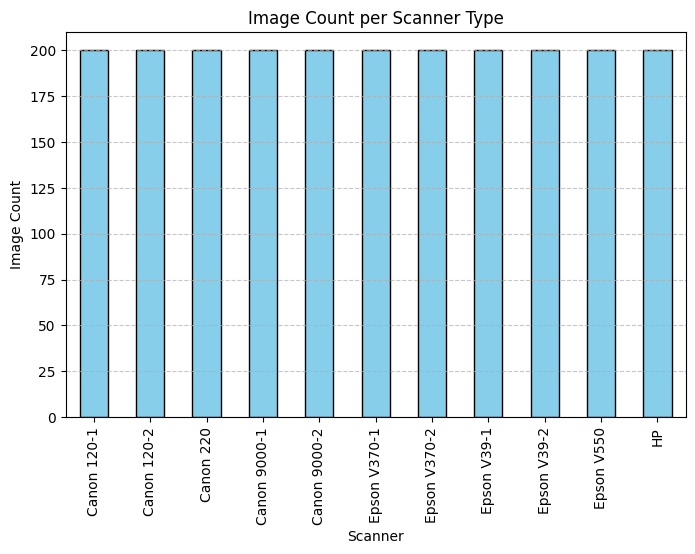

In [6]:
base_path = r"E:\TraceFinder\Dataset"

known_scanners = {
    "canon120-1": "Canon 120-1",
    "canon120-2": "Canon 120-2",
    "canon220": "Canon 220",
    "canon9000-1": "Canon 9000-1",
    "canon9000-2": "Canon 9000-2",
    "epsonv39-1": "Epson V39-1",
    "epsonv39-2": "Epson V39-2",
    "epsonv370-1": "Epson V370-1",
    "epsonv370-2": "Epson V370-2",
    "epsonv550": "Epson V550",
    "hp": "HP",
}

# ✅ Process dataset
metadata = process_dataset_root(base_path, known_scanners)

# ✅ Then plot
if not metadata.empty:
    counts = metadata["scanner_id"].value_counts()
    plt.figure(figsize=(8,5))
    counts.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title("Image Count per Scanner Type")
    plt.xlabel("Scanner")
    plt.ylabel("Image Count")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [7]:
# Prepare data
X = metadata.drop(columns=["file_name", "scanner_id"])
y = metadata["scanner_id"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print(f"🌲 RandomForest accuracy: {accuracy_score(y_test, rf_preds):.4f}")

# SVM
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
print(f"⚙️ SVM accuracy: {accuracy_score(y_test, svm_preds):.4f}")

# Save models
os.makedirs("models", exist_ok=True)
joblib.dump(rf, "models/random_forest.pkl")
joblib.dump(svm, "models/svm.pkl")

print("✅ Models saved in ./models/")


🌲 RandomForest accuracy: 0.4200
⚙️ SVM accuracy: 0.0709
✅ Models saved in ./models/


In [8]:
sample = X_test.sample(5, random_state=42)
rf_sample_preds = rf.predict(sample)
svm_sample_preds = svm.predict(sample)

result = pd.DataFrame({
    "Actual": y_test.loc[sample.index].values,
    "RF_Pred": rf_sample_preds,
    "SVM_Pred": svm_sample_preds
})
result


,Actual,RF_Pred,SVM_Pred
0,Canon 120-2,Canon 120-1,Canon 9000-1
1,Canon 120-2,Canon 120-1,Canon 9000-2
2,Canon 120-2,Canon 120-1,Canon 9000-2
3,Canon 9000-2,Canon 9000-1,Canon 9000-1
4,Canon 120-2,Canon 120-1,Canon 9000-1


In [9]:
summary = metadata.groupby("scanner_id").agg({
    "mean_intensity": "mean",
    "entropy": "mean",
    "edge_density": "mean",
    "contrast": "mean"
}).round(3)

summary.to_csv("dataset_summary.csv")
print("📁 Summary saved to dataset_summary.csv")
summary


📁 Summary saved to dataset_summary.csv


,mean_intensity,entropy,edge_density,contrast
scanner_id,,,,
Canon 120-1,249.422,1.144,0.363,0.831
Canon 120-2,249.513,1.068,0.305,0.823
Canon 220,249.415,1.391,0.508,0.821
Canon 9000-1,249.604,1.051,0.246,0.727
Canon 9000-2,249.655,1.041,0.238,0.715
Epson V370-1,247.493,2.838,0.839,0.577
Epson V370-2,247.600,2.727,0.829,0.584
Epson V39-1,248.997,1.451,0.449,0.787
Epson V39-2,248.946,1.546,0.479,0.782
